In [13]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

In [ ]:
X, y = make_classification(n_samples=5000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=3,
                           n_clusters_per_class=1,
                           weights=[0.01, 0.05, 0.94],
                           class_sep=0.8, random_state=0)

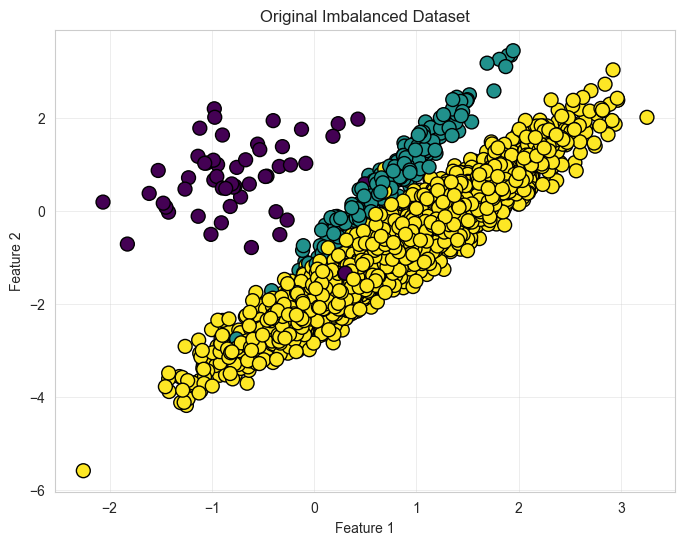

In [33]:
# create a scatter plot to visualize the original imbalanced dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title("Original Imbalanced Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [4]:
# Train on the original imbalanced dataset
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=0)
model.fit(X, y)
y_pred = model.predict(X)

print("Classification Report (Original):")
print(classification_report(y, y_pred))


Classification Report (Original):
              precision    recall  f1-score   support

           0       1.00      0.69      0.81        64
           1       0.96      0.84      0.90       262
           2       0.99      1.00      0.99      4674

    accuracy                           0.99      5000
   macro avg       0.98      0.84      0.90      5000
weighted avg       0.99      0.99      0.99      5000



In [5]:
# calculate balanced accuracy and AUC-ROC for original dataset
balanced_acc = balanced_accuracy_score(y, y_pred)
roc_auc = roc_auc_score(y, model.predict_proba(X), multi_class='ovr')
print(f"Balanced Accuracy (Original): {balanced_acc:.4f}")
print(f"AUC-ROC (Original): {roc_auc:.4f}")

Balanced Accuracy (Original): 0.8435
AUC-ROC (Original): 0.9425


In [38]:
ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)
collected = Counter(y_resampled)
print(sorted(collected.items()))

[(np.int64(0), 4674), (np.int64(1), 4674), (np.int64(2), 4674)]


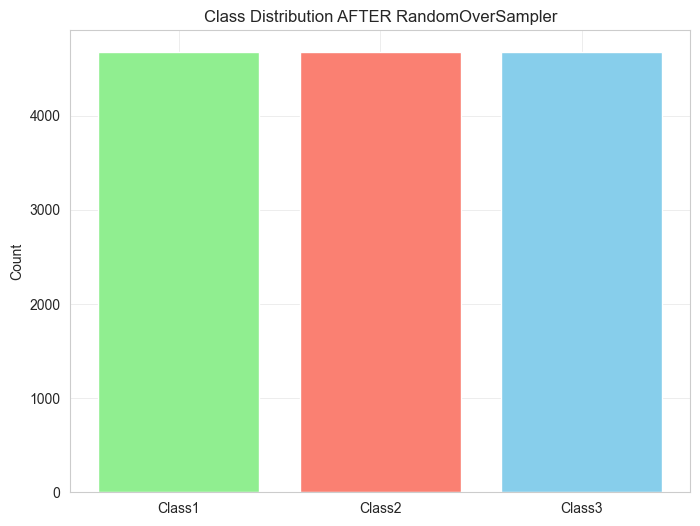

In [40]:
plt.bar(collected.keys(), collected.values(),
        color=['skyblue','salmon', 'lightgreen'])
plt.xticks([0,1,2], ['Class1', 'Class2', 'Class3'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER RandomOverSampler")
plt.show()

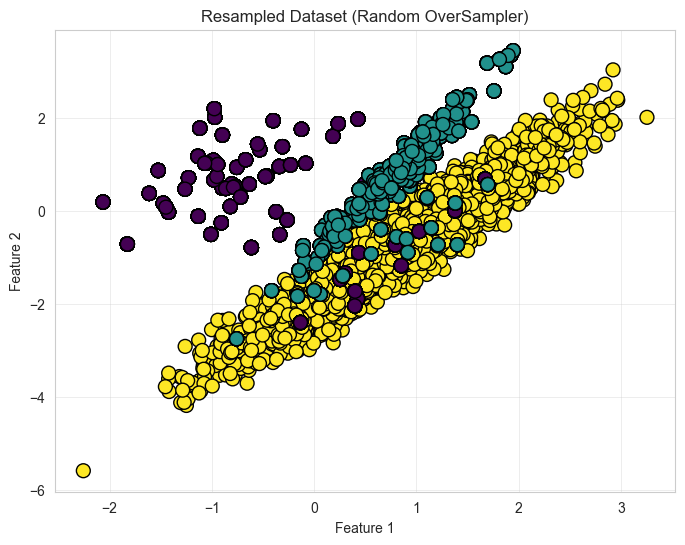

In [41]:
# create a scatter plot to visualize the resampled dataset
plt.scatter(X_resampled[:, 0], X_resampled[:, 1], c=y_resampled, cmap='viridis', edgecolor='k', s=100)
plt.title("Resampled Dataset (Random OverSampler)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [42]:
# Train a logistic regression model on the resampled dataset
clf = LogisticRegression()
clf.fit(X_resampled, y_resampled)

# Predict on the resampled dataset
y_pred = clf.predict(X_resampled)

print("Classification Report (Random OverSampler Resampled):")
print(classification_report(y_resampled, y_pred))

Classification Report (Random OverSampler Resampled):
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      4674
           1       0.92      0.86      0.89      4674
           2       0.79      0.93      0.86      4674

    accuracy                           0.85     14022
   macro avg       0.86      0.85      0.85     14022
weighted avg       0.86      0.85      0.85     14022



In [43]:
# calculate balanced accuracy and AUC-ROC for resampled dataset

balanced_acc = balanced_accuracy_score(y_resampled, y_pred)
roc_auc = roc_auc_score(y_resampled, clf.predict_proba(X_resampled), multi_class='ovr')
print(f"Balanced Accuracy (Resampled): {balanced_acc:.4f}")
print(f"AUC-ROC (Resampled): {roc_auc:.4f}")

Balanced Accuracy (Resampled): 0.8527
AUC-ROC (Resampled): 0.9188


In [44]:
#  Apply SMOTE to Balance Classes
smote = SMOTE(random_state=0, sampling_strategy='auto')
X_resampled, y_resampled = smote.fit_resample(X, y)

collected = Counter(y_resampled)
collected

Counter({np.int64(2): 4674, np.int64(1): 4674, np.int64(0): 4674})

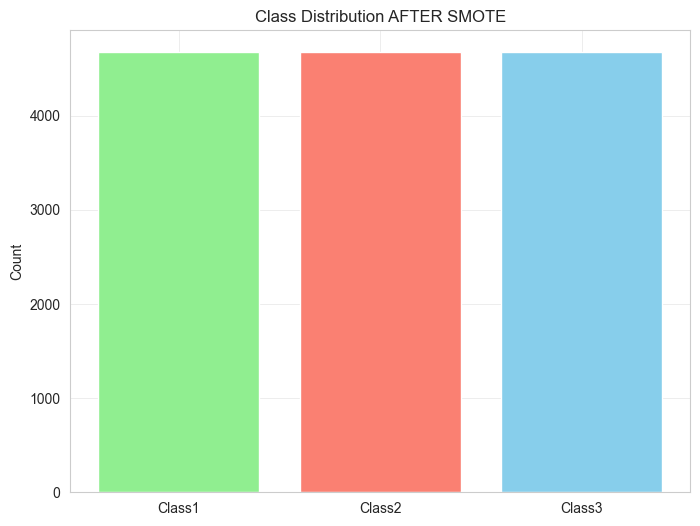

In [45]:
plt.bar(collected.keys(), collected.values(),
        color=['skyblue','salmon', 'lightgreen'])
plt.xticks([0,1,2], ['Class1', 'Class2', 'Class3'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

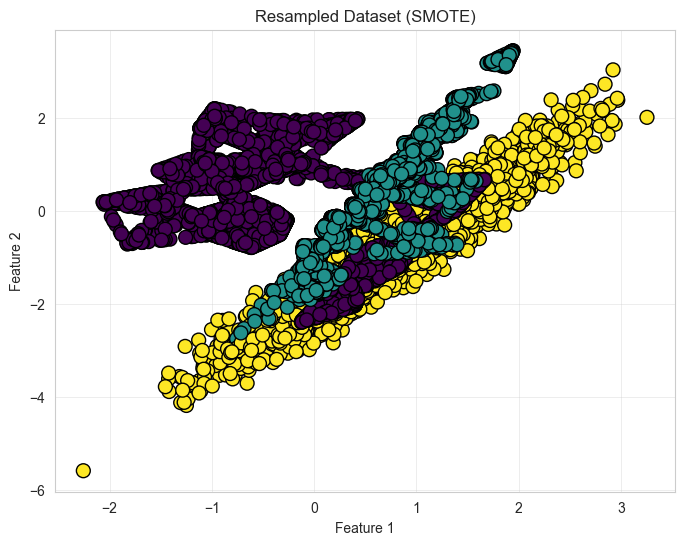

In [46]:
# create a scatter plot to visualize the resampled dataset
plt.scatter(X_resampled[:, 0], X_resampled[:, 1], c=y_resampled, cmap='viridis', edgecolor='k', s=100)
plt.title("Resampled Dataset (SMOTE)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [47]:
# Train a logistic regression model on the SMOTE resampled dataset
clf = LogisticRegression()
clf.fit(X_resampled, y_resampled)

# Predict on the SMOTE resampled dataset
y_pred = clf.predict(X_resampled)

print("Classification Report (SMOTE Resampled):")
print(classification_report(y_resampled, y_pred))

Classification Report (SMOTE Resampled):
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4674
           1       0.92      0.89      0.90      4674
           2       0.81      0.93      0.87      4674

    accuracy                           0.87     14022
   macro avg       0.87      0.87      0.87     14022
weighted avg       0.87      0.87      0.87     14022



In [48]:
# calculate balanced accuracy and AUC-ROC for SMOTE resampled dataset
balanced_acc = balanced_accuracy_score(y_resampled, y_pred)
roc_auc = roc_auc_score(y_resampled, clf.predict_proba(X_resampled), multi_class='ovr')
print(f"Balanced Accuracy (SMOTE Resampled): {balanced_acc:.4f}")
print(f"AUC-ROC (SMOTE Resampled): {roc_auc:.4f}")

Balanced Accuracy (SMOTE Resampled): 0.8670
AUC-ROC (SMOTE Resampled): 0.9279


In [49]:
# use ADASYN to balance classes
adasyn = ADASYN(random_state=0, sampling_strategy='auto')
X_resampled, y_resampled = adasyn.fit_resample(X, y)

In [50]:
collected = Counter(y_resampled)
print(sorted(collected.items()))

[(np.int64(0), 4673), (np.int64(1), 4662), (np.int64(2), 4674)]


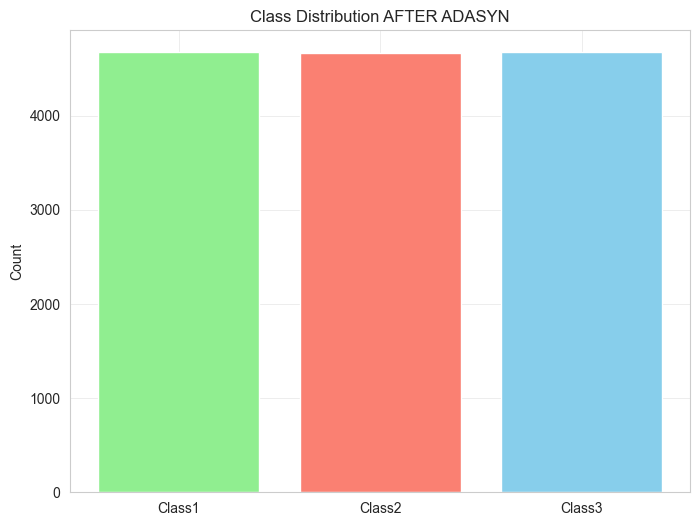

In [51]:
plt.bar(collected.keys(), collected.values(),
        color=['skyblue','salmon', 'lightgreen'])
plt.xticks([0,1,2], ['Class1', 'Class2', 'Class3'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER ADASYN")
plt.show()

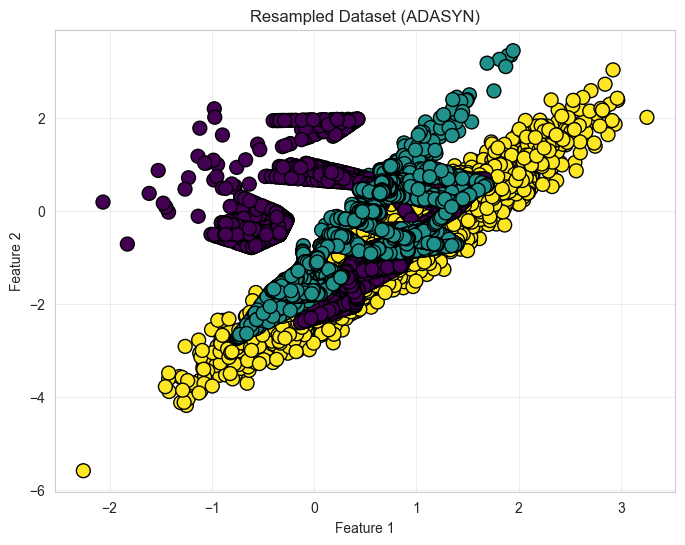

In [52]:
# create a scatter plot to visualize the resampled dataset
plt.scatter(X_resampled[:, 0], X_resampled[:, 1], c=y_resampled, cmap='viridis', edgecolor='k', s=100)
plt.title("Resampled Dataset (ADASYN)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [53]:
# Train a logistic regression model on the ADASYN resampled dataset
clf = LogisticRegression()
clf.fit(X_resampled, y_resampled)

# Predict on the ADASYN resampled dataset
y_pred = clf.predict(X_resampled)

In [54]:
print("Classification Report (ADASYN Resampled):")
print(classification_report(y_resampled, y_pred))

Classification Report (ADASYN Resampled):
              precision    recall  f1-score   support

           0       0.20      0.16      0.18      4673
           1       0.51      0.37      0.43      4662
           2       0.49      0.72      0.58      4674

    accuracy                           0.42     14009
   macro avg       0.40      0.42      0.39     14009
weighted avg       0.40      0.42      0.39     14009



In [55]:
# calculate balanced accuracy and AUC-ROC for ADASYN resampled dataset
balanced_acc = balanced_accuracy_score(y_resampled, y_pred)
roc_auc = roc_auc_score(y_resampled, clf.predict_proba(X_resampled), multi_class='ovr')
print(f"Balanced Accuracy (ADASYN Resampled): {balanced_acc:.4f}")
print(f"AUC-ROC (ADASYN Resampled): {roc_auc:.4f}")

Balanced Accuracy (ADASYN Resampled): 0.4154
AUC-ROC (ADASYN Resampled): 0.6597
